In [1]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed, add_quality, add_stage, add_elo
from source.make_train_test import make_teams_target, make_training_data


In [2]:
women_reg = pd.read_csv('data/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv')
women_reg_details = process_details(women_reg)
women_reg = full_stats(women_reg_details)
women_reg = add_seed('data/march-machine-learning-mania-2026/WNCAATourneySeeds.csv', women_reg)
women_reg = add_elo(women_reg_details, women_reg)

women_reg.head()

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,...,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc,Seed,region,elo
0,2010,3102,10.250000,0.707342,-0.743389,-9.285714,0.000000,0.642857,-4.392857,19.535714,...,0.678378,0.464552,0.439484,0.570219,0.403226,0.547182,0.0,NaN,NaN,588.037546
1,2010,3103,13.385185,0.771411,0.105735,1.718519,0.200000,2.392593,-1.381481,23.477778,...,0.704955,0.395955,0.487150,0.471448,0.438194,0.425458,1.0,NaN,NaN,1115.809868
2,2010,3104,12.957854,0.713131,-0.018906,0.586207,0.172414,2.900383,-0.655172,25.559387,...,0.614815,0.469074,0.462105,0.480104,0.433959,0.440010,0.0,NaN,NaN,1008.454605
3,2010,3105,9.740741,0.396486,-0.305999,-3.740741,0.259259,5.148148,0.740741,23.370370,...,0.698630,0.521818,0.493659,0.476970,0.430444,0.428525,0.0,NaN,NaN,865.620550
4,2010,3106,11.459770,0.628753,0.101944,1.984674,0.172414,4.459770,0.513410,24.643678,...,0.648306,0.376355,0.433730,0.460022,0.373466,0.389745,1.0,NaN,NaN,912.855590


In [3]:
women_target_data = pd.read_csv('data/march-machine-learning-mania-2026/WNCAATourneyCompactResults.csv')
women_target_data = make_teams_target(women_target_data, "women")

In [5]:
women_training = make_training_data(women_reg, women_target_data)
women_training = add_stage(women_training)
women_training = add_quality(women_training, women_reg_details)
women_training  = women_training[women_training.DayNum >= 136]  # remove pre tourney 

women_training.to_csv("data/processed/women_training.csv", index=False)
women_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality
0,2010,138,3124,3201,1,14,0,0,2010_3124_3201,14.645833,...,True,False,False,False,False,False,False,2961.988207,663.448704,2298.539503
1,2010,138,3173,3395,1,1,0,0,2010_3173_3395,14.217094,...,True,False,False,False,False,False,False,980.038632,597.619818,382.418813
2,2010,138,3181,3214,1,35,1,-1,2010_3181_3214,14.250000,...,True,False,False,False,False,False,False,5829.890930,28.912893,5800.978037
3,2010,138,3199,3256,1,14,1,-1,2010_3199_3256,15.333333,...,True,False,False,False,False,False,False,2367.995688,267.981411,2100.014277
4,2010,138,3207,3265,1,20,0,0,2010_3207_3265,15.737778,...,True,False,False,False,False,False,False,2294.843970,215.010415,2079.833555


# Winning target

In [13]:
target = "target"
col_to_use = [c for c in women_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = women_training[col_to_use].copy()

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,target
0,2010,138,3124,3201,0,0,14.645833,0.960982,0.234959,5.184028,...,False,False,False,False,False,False,2961.988207,663.448704,2298.539503,1
1,2010,138,3173,3395,0,0,14.217094,0.914254,0.217113,2.745299,...,False,False,False,False,False,False,980.038632,597.619818,382.418813,1
2,2010,138,3181,3214,1,-1,14.250000,0.852429,0.301442,2.875000,...,False,False,False,False,False,False,5829.890930,28.912893,5800.978037,1
3,2010,138,3199,3256,1,-1,15.333333,0.856378,0.163884,3.100000,...,False,False,False,False,False,False,2367.995688,267.981411,2100.014277,1
4,2010,138,3207,3265,0,0,15.737778,1.052713,0.453464,2.608889,...,False,False,False,False,False,False,2294.843970,215.010415,2079.833555,1


In [14]:
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

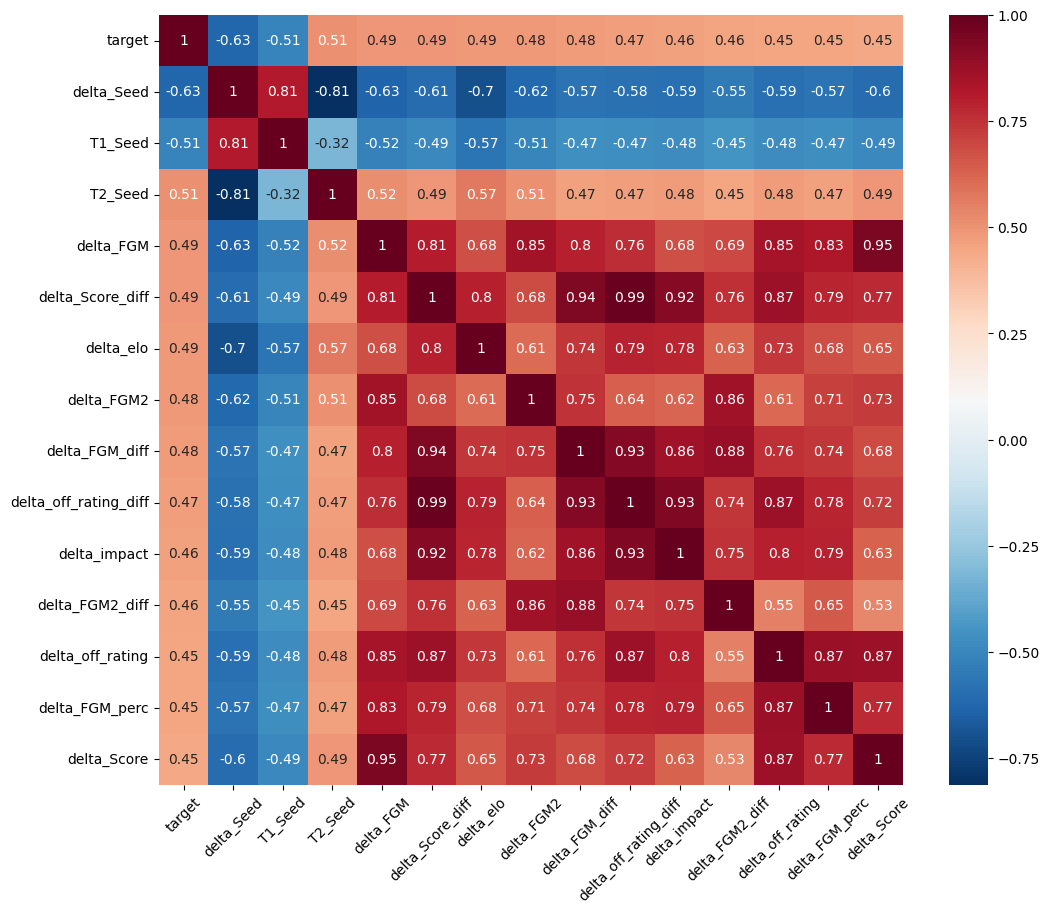

In [15]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

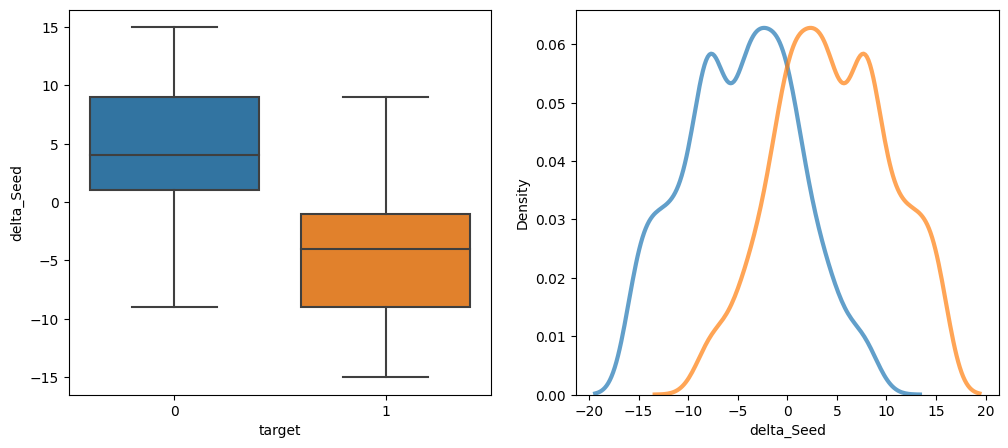

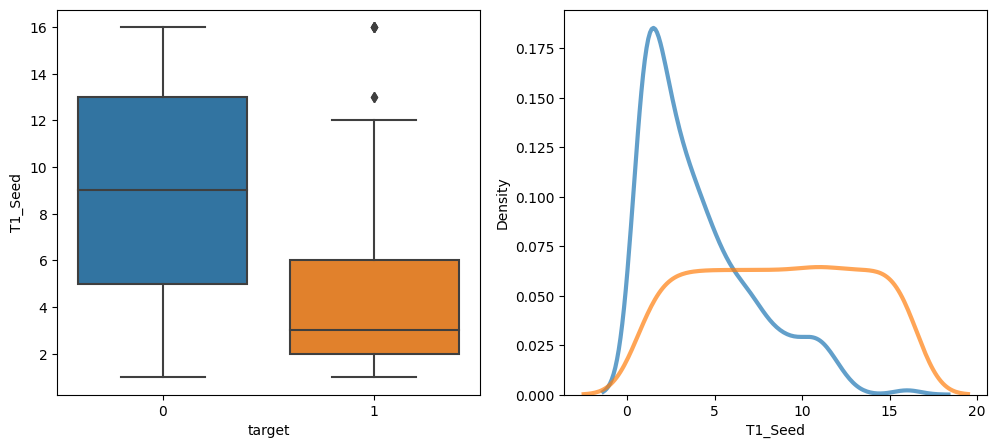

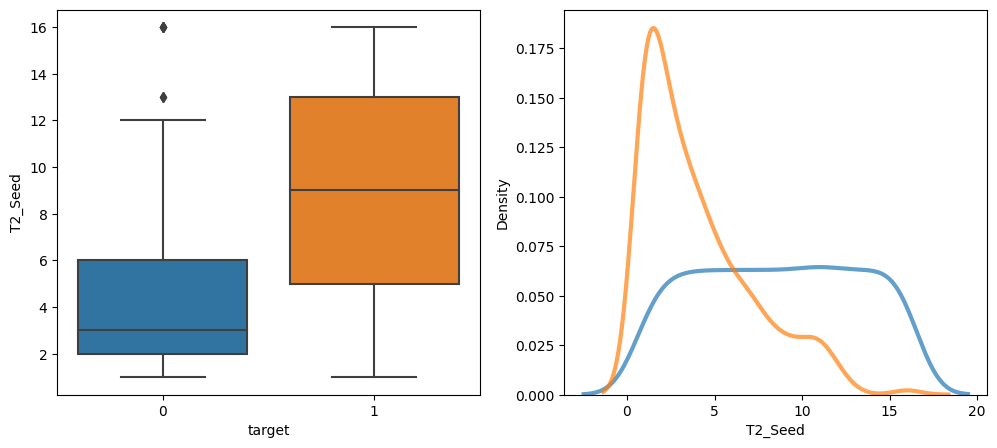

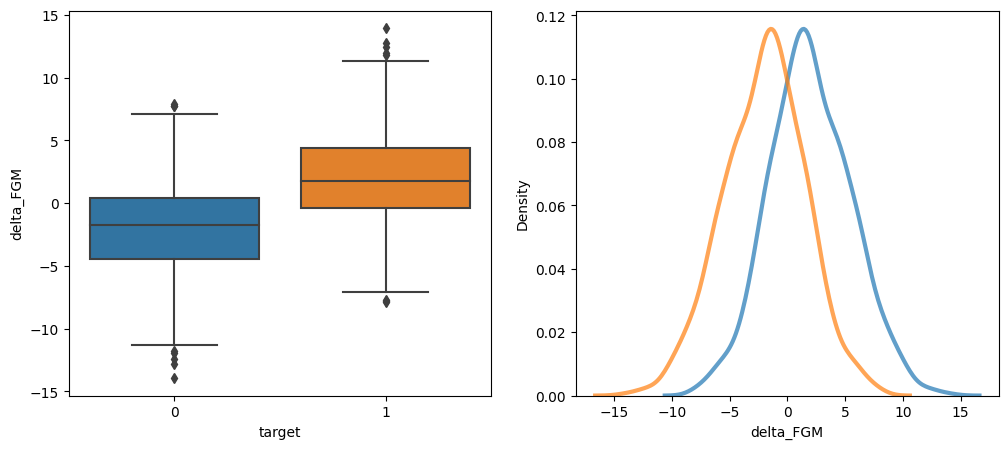

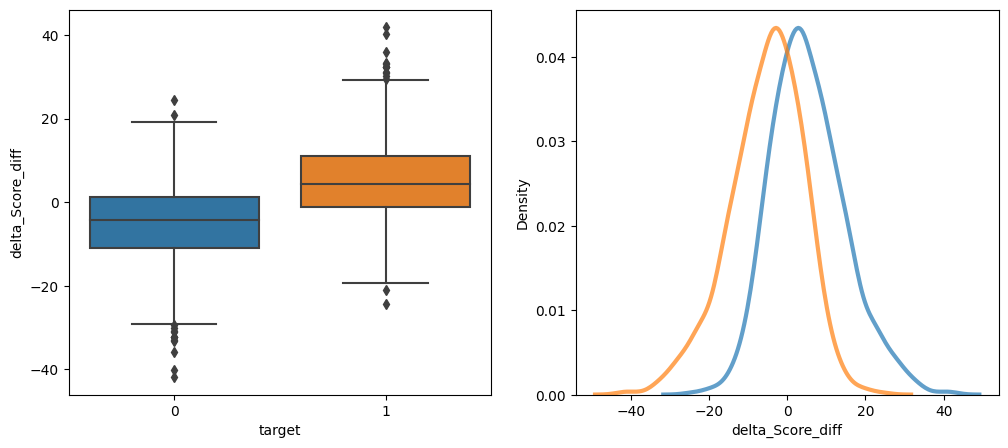

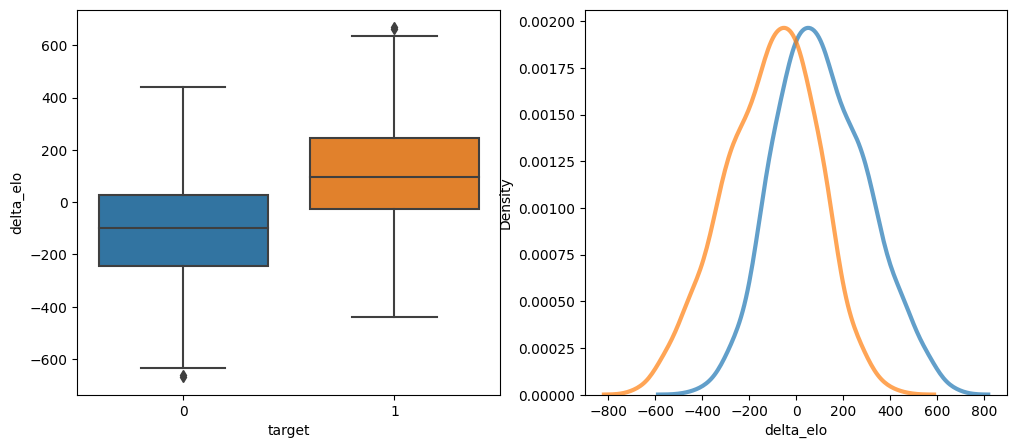

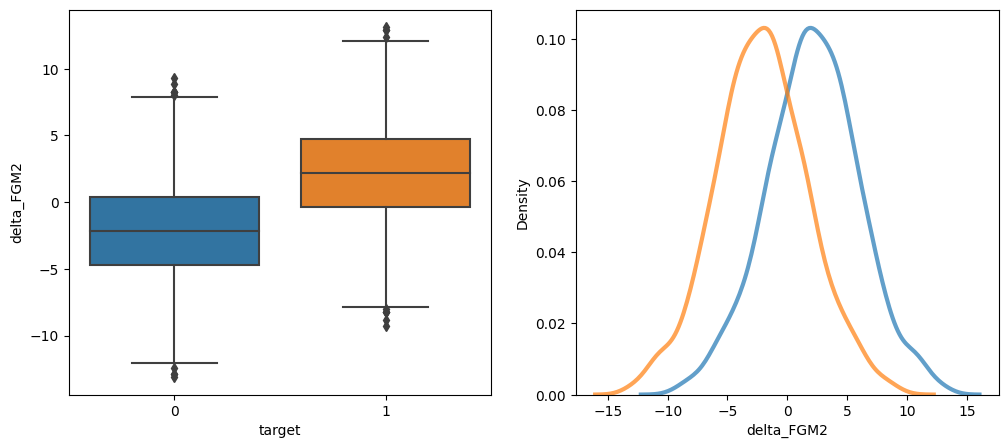

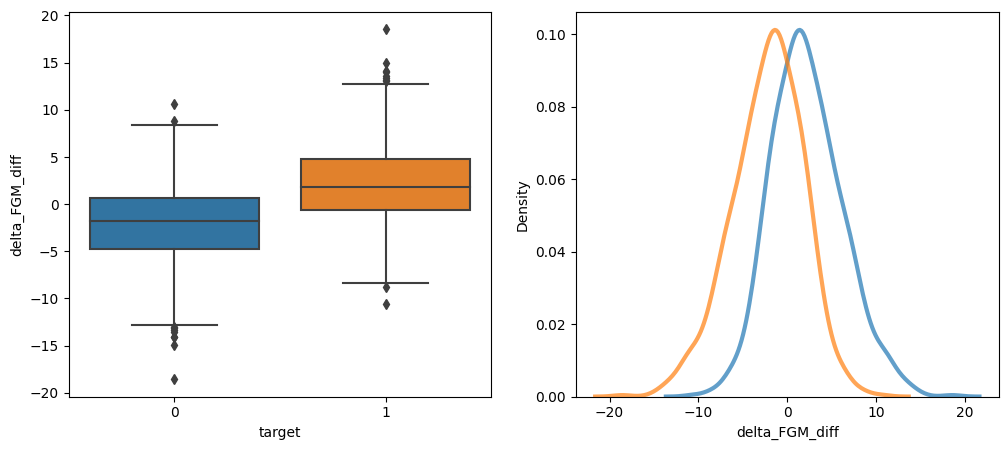

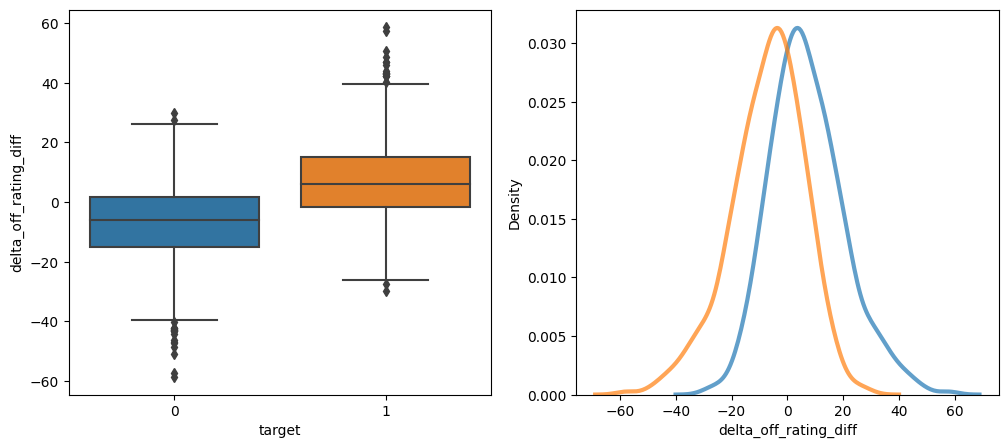

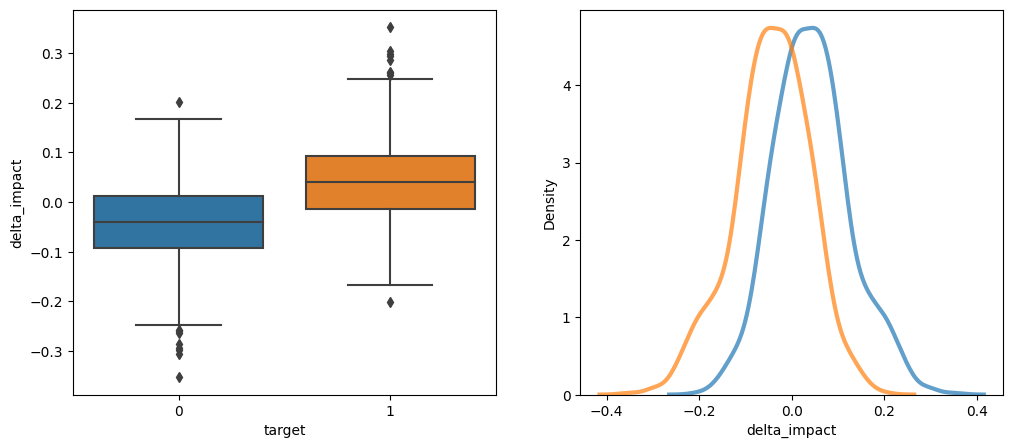

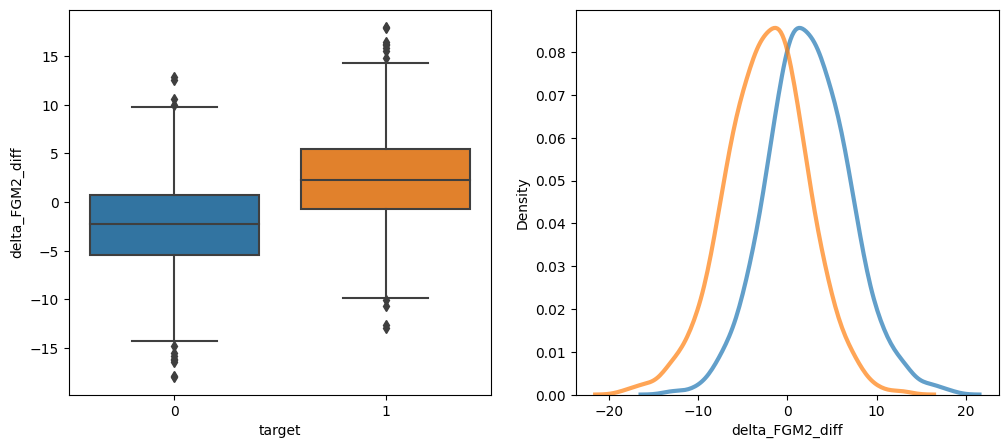

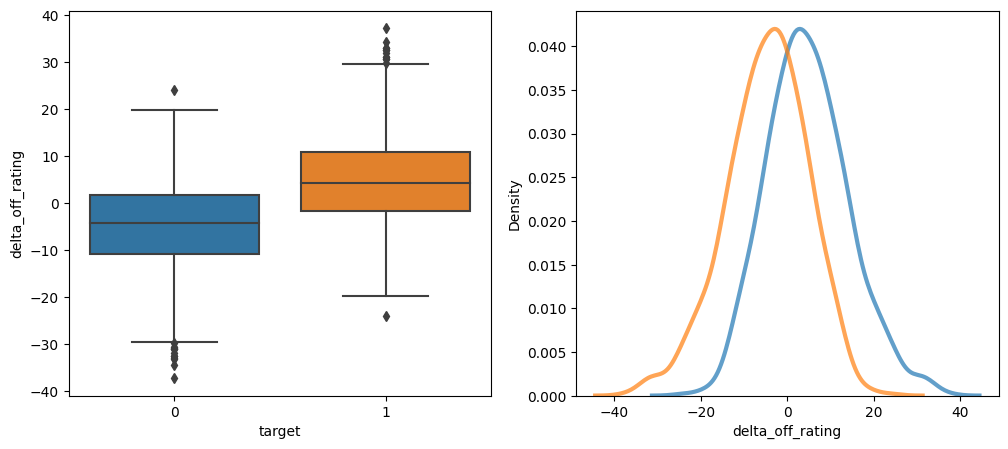

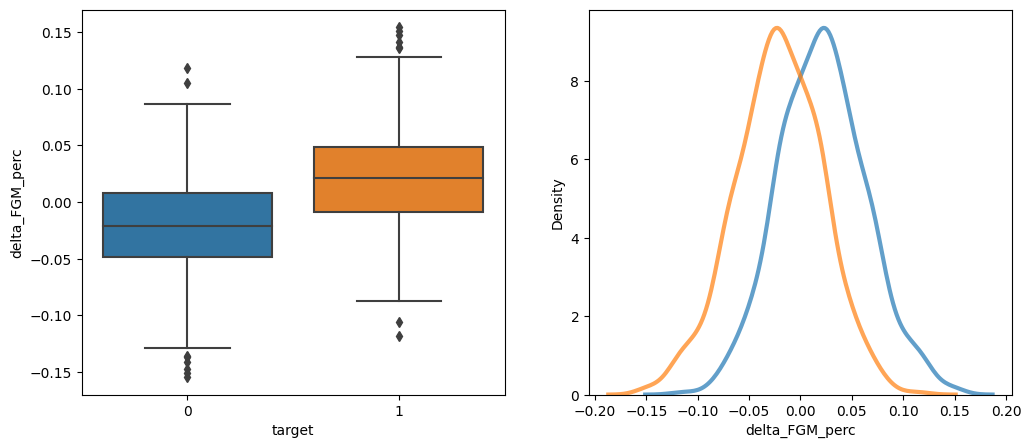

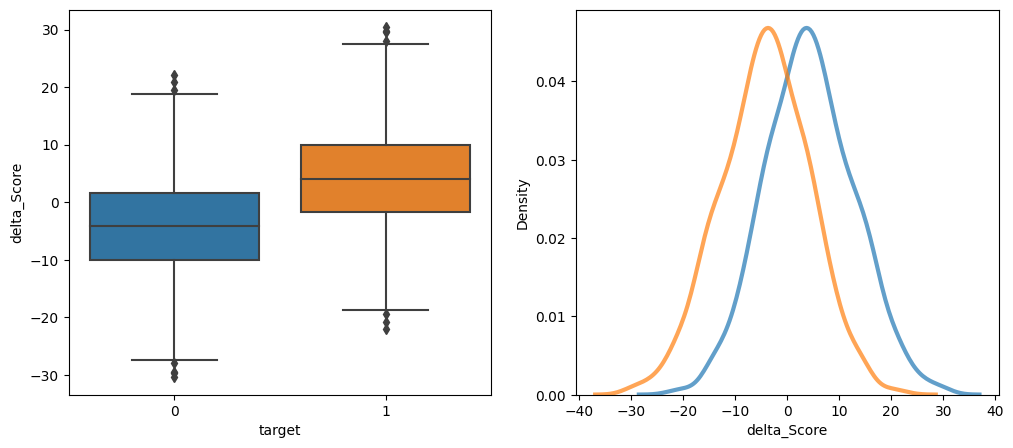

In [16]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [17]:
target = "target_points"
col_to_use = [c for c in women_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = women_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,T1_quality,T2_quality,delta_quality,target_points
0,2010,138,3124,3201,0,0,14.645833,0.960982,0.234959,5.184028,...,False,False,False,False,False,False,2961.988207,663.448704,2298.539503,14
1,2010,138,3173,3395,0,0,14.217094,0.914254,0.217113,2.745299,...,False,False,False,False,False,False,980.038632,597.619818,382.418813,1
2,2010,138,3181,3214,1,-1,14.250000,0.852429,0.301442,2.875000,...,False,False,False,False,False,False,5829.890930,28.912893,5800.978037,35
3,2010,138,3199,3256,1,-1,15.333333,0.856378,0.163884,3.100000,...,False,False,False,False,False,False,2367.995688,267.981411,2100.014277,14
4,2010,138,3207,3265,0,0,15.737778,1.052713,0.453464,2.608889,...,False,False,False,False,False,False,2294.843970,215.010415,2079.833555,20


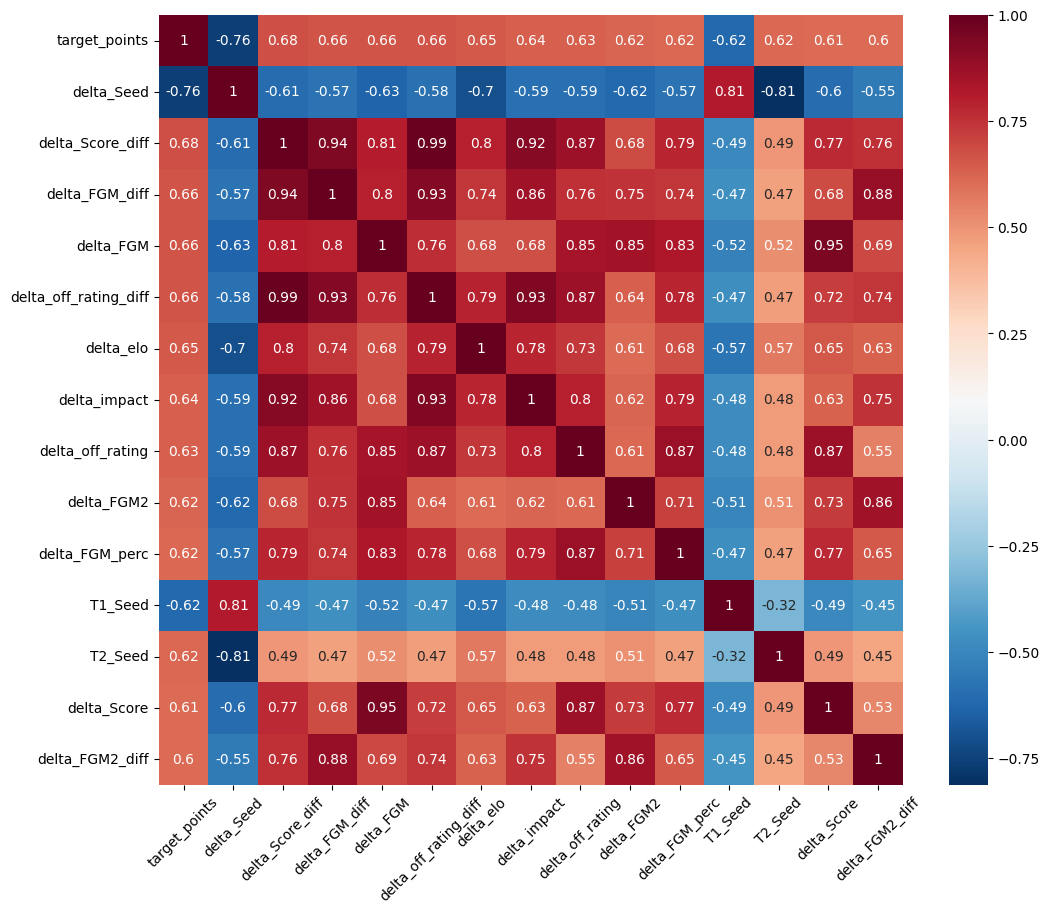

In [18]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

                       delta_Seed  delta_Score_diff  delta_FGM_diff  \
delta_Seed               1.000000         -0.605725       -0.572548   
delta_Score_diff        -0.605725          1.000000        0.940794   
delta_FGM_diff          -0.572548          0.940794        1.000000   
delta_FGM               -0.634739          0.806980        0.797553   
delta_off_rating_diff   -0.579630          0.992810        0.927802   
delta_elo               -0.702881          0.795314        0.739133   
delta_impact            -0.587147          0.917650        0.859032   
delta_off_rating        -0.587156          0.866704        0.756311   
delta_FGM2              -0.621623          0.682606        0.751123   
delta_FGM_perc          -0.573690          0.785029        0.743382   
T1_Seed                  0.813143         -0.492541       -0.465564   
T2_Seed                 -0.813143          0.492541        0.465564   
delta_Score             -0.603950          0.769650        0.682906   
delta_

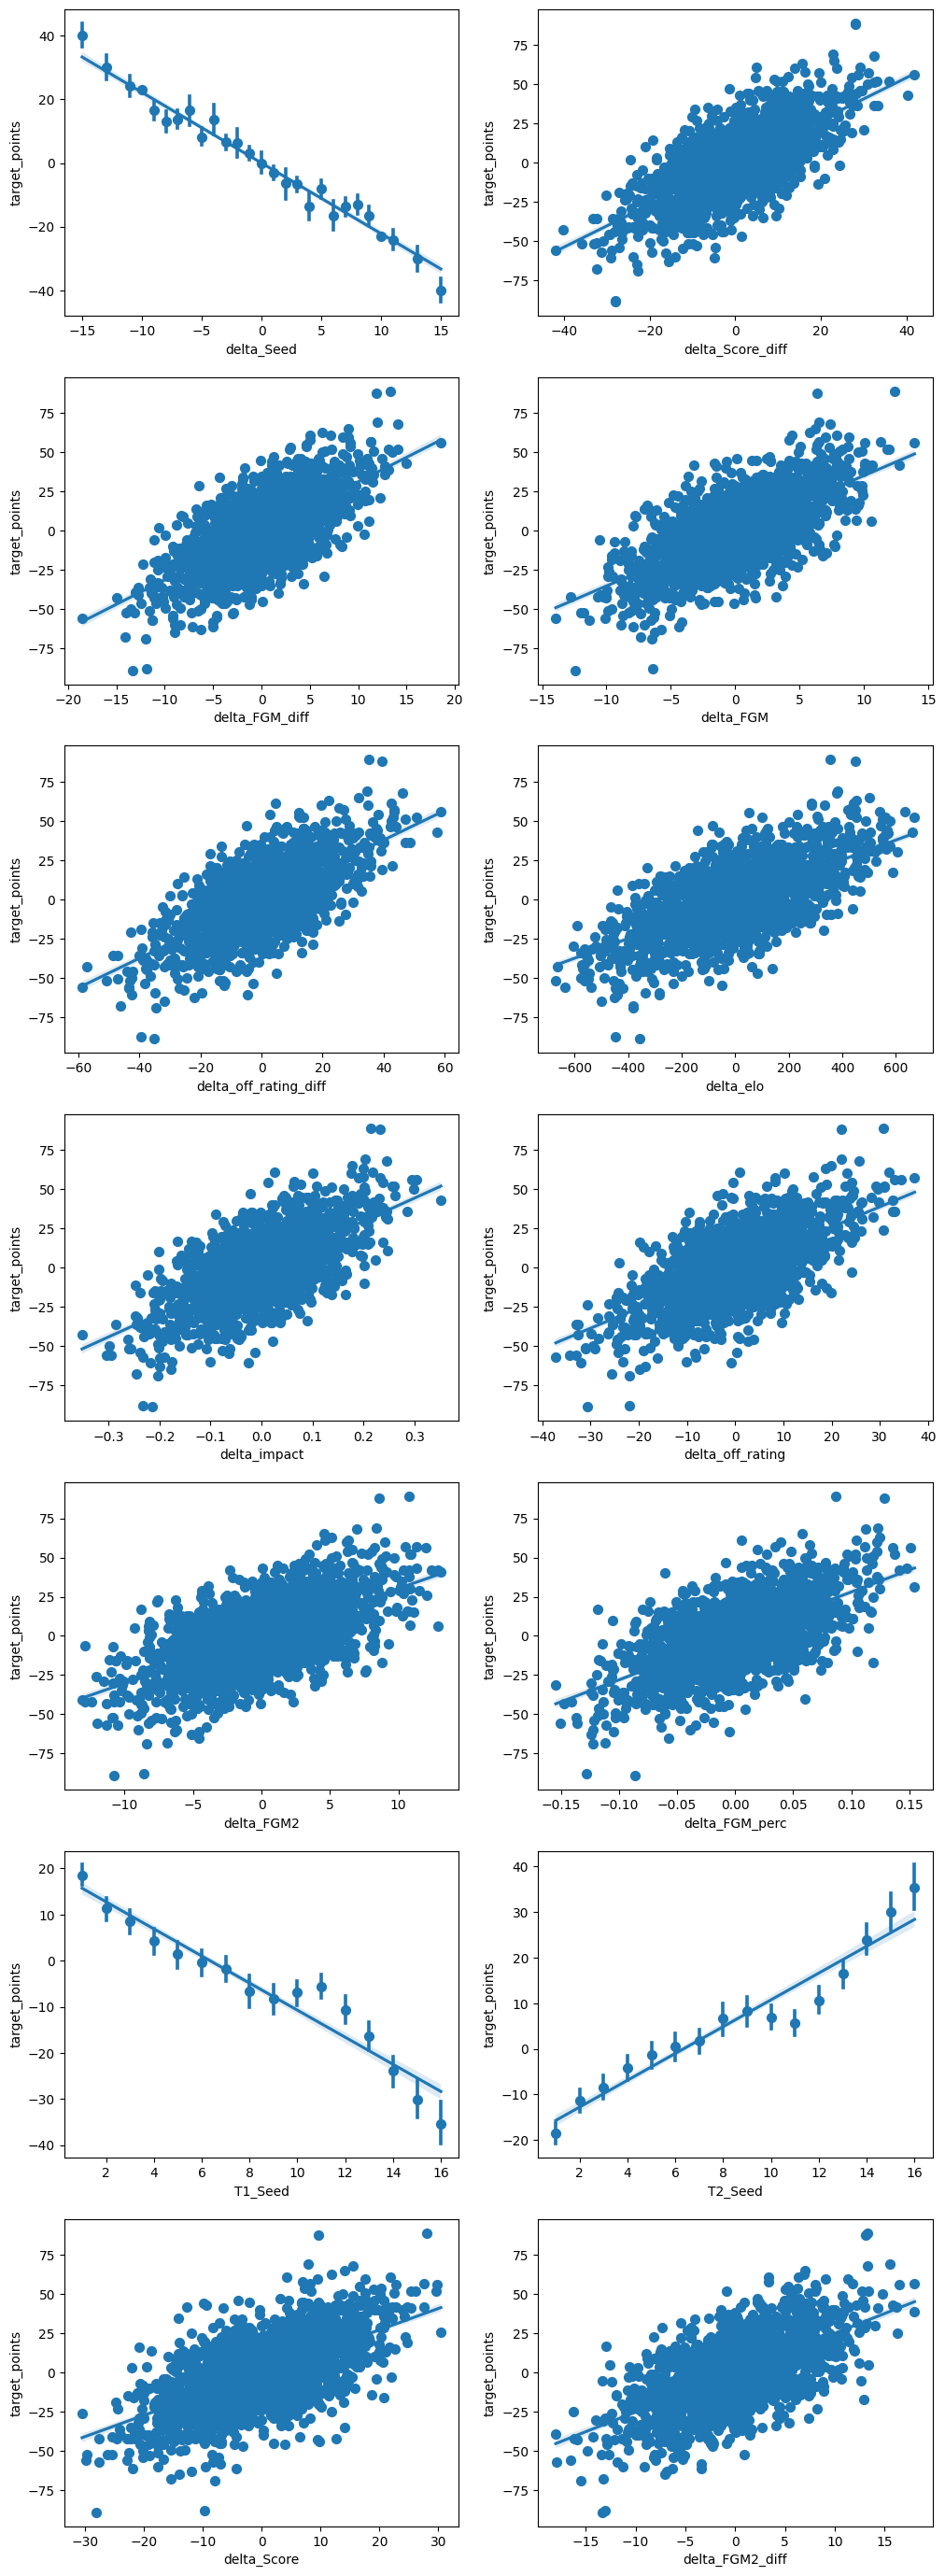

In [19]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)